# Step 1

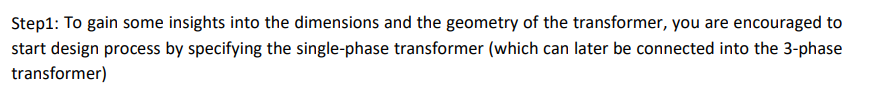

We work with a Shell-type transformer.

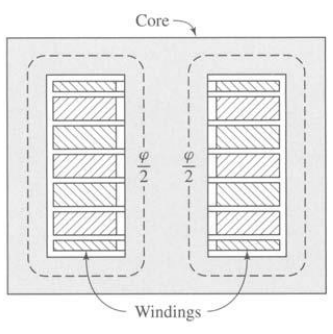

Although the primary and secondary windings are layed on top of each other, and flux between these terminals behave differently than if it were a Core-type, then we will still use this simplified schematic analyze the transformer. The essensial features still remain the same, as they also argue in the book.

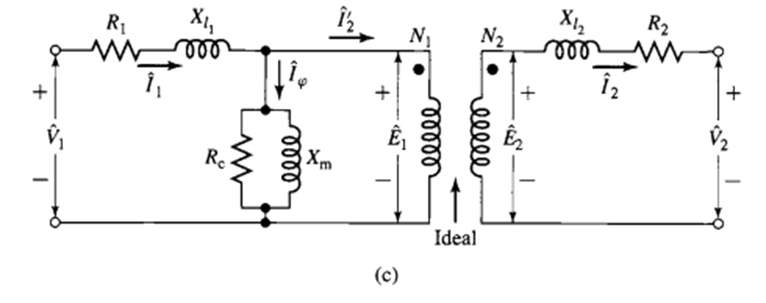

or as 

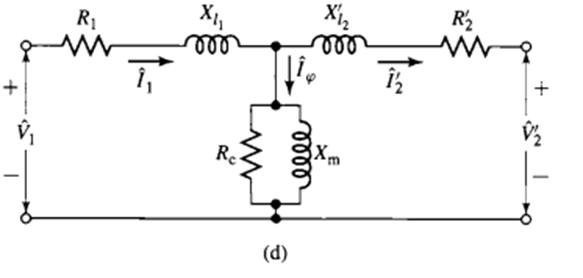

if this holds:

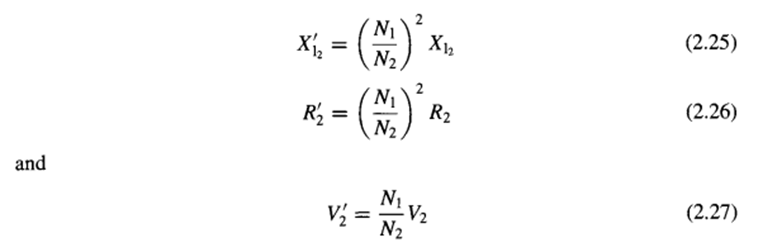


Since we start by analyzing a 1-phase trafo, then the VA rating is 


In [46]:
# For a 3-phase trasnformer

S_rating_3ph = 3000*10**3

# For a 1-phase transformer

S_rating = S_rating_3ph/3
print(f"{S_rating} VA")

1000000.0 VA


# Step 2

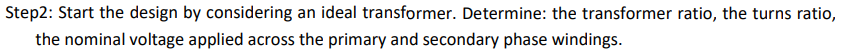

In [47]:
# First off, let us convert the voltages. Since we work with a Y/Delta configuration, 
# and Y have a Neutral, then to correctly analyze a 1-phase, we must investigate the LN voltage
# Since Delta does not have a Neutral, then the voltage is the same as the nominal

import numpy as np

V_pri = 36*10**3/np.sqrt(3) # [V]
V_sec = 3*10**3 # [V]

print(f"V_pri: {V_pri}")
print(f"V_sec: {V_sec}\n")

#  The ratio is therefore

print(f"Ratio: {V_pri/V_sec}\n")

# Our turn ratio is limited by the K_insulation at 1.5V/turn.
# The turns on the primary and secondary terminal is

K_insulation = 1.5 # [V/turn]

N_pri = V_pri/K_insulation
N_sec = V_sec/K_insulation

print(f"N_pri: {N_pri}")
print(f"N_sec: {N_sec}\n")



V_pri: 20784.609690826528
V_sec: 3000

Ratio: 6.92820323027551

N_pri: 13856.40646055102
N_sec: 2000.0



# Step 3

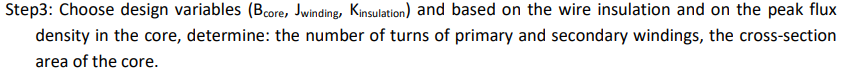

In [48]:
# The conducting capabilities, restricted by the nominal voltage on the primary and secondary 
# terminal is determined whether we work with Y or Delta connected trafos.
# Normal formula for LL is
# S = sqrt(3) * I_RMS * V_RMS_LL
# And for LN
# S = I_RMS * V_RMS_LN
# this is a change
# Using these formulas, let us first find the conducting current in the primary and secondary windings
A_pri = S_rating/V_pri # [A]
A_sec = S_rating/V_sec # [A]

print(f"A_pri: {A_pri:.3f} A, A_sec: {A_sec:.3f} A\n")


print("NEXT PART: Let us find the cross sectional area of the conducting windings")

# For copper, the normal max current density is much higher around 10 A/mm² (https://en.wikipedia.org/wiki/Copper). 
# We are working with fairly smaller numbers here. The max current density is 0.5 A/mm^2 for copper 
# if air is cooling it, and 0.75 if oil is cooling it.
# For Aluminium the normal current density around copper in low dimension, but lower than copper when approaching higher dimension (https://www.engineeringtoolbox.com/maximum-current-copper-aluminum-wire-d_1690.html). 
# Let us say its 0.3 A/mm2 for air cooling and 0.4 for oil cooling.

J_CUair = 0.5 # [A / mm2]
J_CUoil = 0.75 # [A / mm2]
J_ALair = 0.3 # [A / mm2]
J_ALoil = 0.4 # [A / mm2]

J_list = [
    {"material": "Cu", "cooling": "air", "J": J_CUair},
    {"material": "Cu", "cooling": "oil", "J": J_CUoil},
    {"material": "Al", "cooling": "air", "J": J_ALair},
    {"material": "Al", "cooling": "oil", "J": J_ALoil},
]

# For primary terminal:
# We have a insulation between windings of 0.5 mm, 
# We also have a insulating layer between the windings of minimum 20mm.

d_insul = 0.5 # [mm]


def winding_cross_area(J_list, current, print_results):
    for cases in J_list:
        J = cases["J"]                              # [A/mm^2]
        A_cond = current/J                            # [mm^2] conductor area
        r_bare = np.sqrt(A_cond / np.pi)            # [mm] conductor radius (round wire)
        r_out = r_bare + d_insul                    # [mm] radius including insulation
        A_out = np.pi * r_out**2                    # [mm^2] area incl. insulation

        if print_results:
            print(
                f"For {cases['material']} with cooling: {cases['cooling']}: "
                f"J={J:.3f} A/mm^2, A_cond={A_cond:.2f} mm^2, "
                f"r_out={r_out:.3f} mm, A_out={A_out:.2f} mm^2"
            )
    if print_results:
        print("")

print("For primary terminal:\n")
winding_cross_area(J_list, A_pri, True)

print("For secondary terminal:\n")
winding_cross_area(J_list, A_sec, True)


print("NEXT PART: Finding the cross area of of the core")

# This formula is used:
# E_rms = sqrt(2) * Pi * N * f * phi_max
# Based on the nominal voltages of the 1-phase investigation, the max phi is:

f = 50 # [Hz]

Phi_max_pri = V_pri / (np.sqrt(2) * np.pi * N_pri * f) # [Wb]
Phi_max_sec = V_sec / (np.sqrt(2) * np.pi * N_pri * f) # [Wb]

print(f"Phi_max for primary: {Phi_max_pri:.3f} Wb, Phi_max for secondary: {Phi_max_sec:.3f} Wb")

# The magnetic flux can, according to the assignment, range from 0.1 - 1.5 T. Let us just start with 1.5 T

B_core = 1.5 # [T]
Area_core_pri = Phi_max_pri/B_core # [m^2]
side_core_pri = np.sqrt(Area_core_pri)

print(f"Minimum core area (not counting stacking factor) for the primary side: {Area_core_pri * 10**6:.3f} mm2, with a side of {side_core_pri * 10**3:.3f} mm")

# Since we have a stacking factor of 90%, this means that now all of the core is able to conduct the flux. Therefore the actual minimum should be:
Area_core_pri = Area_core_pri/0.9 # [m^2]
side_core_pri = np.sqrt(Area_core_pri)

print(f"Minimum core area for the primary side: {Area_core_pri * 10**6:.3f} mm2, with a side of {side_core_pri * 10**3:.3f} mm")


A_pri: 48.113 A, A_sec: 333.333 A

NEXT PART: Let us find the cross sectional area of the conducting windings
For primary terminal:

For Cu with cooling: air: J=0.500 A/mm^2, A_cond=96.23 mm^2, r_out=6.034 mm, A_out=114.40 mm^2
For Cu with cooling: oil: J=0.750 A/mm^2, A_cond=64.15 mm^2, r_out=5.019 mm, A_out=79.13 mm^2
For Al with cooling: air: J=0.300 A/mm^2, A_cond=160.38 mm^2, r_out=7.645 mm, A_out=183.61 mm^2
For Al with cooling: oil: J=0.400 A/mm^2, A_cond=120.28 mm^2, r_out=6.688 mm, A_out=140.51 mm^2

For secondary terminal:

For Cu with cooling: air: J=0.500 A/mm^2, A_cond=666.67 mm^2, r_out=15.067 mm, A_out=713.22 mm^2
For Cu with cooling: oil: J=0.750 A/mm^2, A_cond=444.44 mm^2, r_out=12.394 mm, A_out=482.60 mm^2
For Al with cooling: air: J=0.300 A/mm^2, A_cond=1111.11 mm^2, r_out=19.306 mm, A_out=1170.98 mm^2
For Al with cooling: oil: J=0.400 A/mm^2, A_cond=833.33 mm^2, r_out=16.787 mm, A_out=885.29 mm^2

NEXT PART: Finding the cross area of of the core
Phi_max for primary:

# Step 4

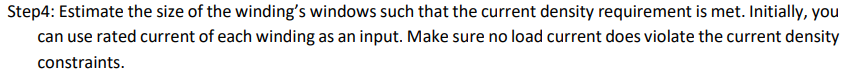

In [49]:
import math

def main():
    # -----------------------------
    # Inputs
    # -----------------------------
    Sphase = 3000 / 3 * 1e3       # VA
    VpriLL = 36e3                 # V
    VsecLL = 3e3                  # V
    f = 50.0                      # Hz

    Npri = 24000
    Nsec = 2000

    Ipri_rated = Sphase / VpriLL  # A
    Isec_rated = Sphase / VsecLL  # A

    Jair = 0.5                    # A/mm^2
    Joil = 0.75                   # A/mm^2

    t_ins_mm = 0.5                # mm
    clear_core_mm = 20.0          # mm
    clear_between_mm = 20.0       # mm

    kw = 0.35
    J = Jair                      # choose air cooling case
    AR = 3.0                      # h_window / w_window

    # -----------------------------
    # Conductor metal areas
    # -----------------------------
    Ametal_pri_mm2 = Ipri_rated / J
    Ametal_sec_mm2 = Isec_rated / J

    # -----------------------------
    # Wire dimensions
    # -----------------------------
    r_m_pri_mm = math.sqrt(Ametal_pri_mm2 / math.pi)
    r_out_pri_mm = r_m_pri_mm + t_ins_mm
    Awire_pri_mm2 = math.pi * r_out_pri_mm**2

    r_m_sec_mm = math.sqrt(Ametal_sec_mm2 / math.pi)
    r_out_sec_mm = r_m_sec_mm + t_ins_mm
    Awire_sec_mm2 = math.pi * r_out_sec_mm**2

    # -----------------------------
    # Current density check
    # -----------------------------
    J_pri_check = Ipri_rated / (math.pi * r_m_pri_mm**2)
    J_sec_check = Isec_rated / (math.pi * r_m_sec_mm**2)

    # -----------------------------
    # Total occupied winding area
    # -----------------------------
    Aturns_total_mm2 = Npri * Awire_pri_mm2 + Nsec * Awire_sec_mm2
    Aw_required_mm2 = Aturns_total_mm2 / kw

    # -----------------------------
    # Window dimensions
    # -----------------------------
    w_window_mm = math.sqrt(Aw_required_mm2 / AR)
    h_window_mm = AR * w_window_mm

    w_window_gross_mm = w_window_mm + 2 * clear_core_mm + clear_between_mm
    h_window_gross_mm = h_window_mm + 2 * clear_core_mm

    # -----------------------------
    # Print results
    # -----------------------------
    print("Inputs:")
    print(f"Sphase         = {Sphase:.6f} VA")
    print(f"VpriLL         = {VpriLL:.6f} V")
    print(f"VsecLL         = {VsecLL:.6f} V")
    print(f"f              = {f:.6f} Hz")
    print(f"Npri           = {Npri}")
    print(f"Nsec           = {Nsec}")
    print(f"Ipri_rated     = {Ipri_rated:.6f} A")
    print(f"Isec_rated     = {Isec_rated:.6f} A")
    print(f"Jair           = {Jair:.6f} A/mm^2")
    print(f"Joil           = {Joil:.6f} A/mm^2")
    print(f"J used         = {J:.6f} A/mm^2")
    print(f"t_ins          = {t_ins_mm:.6f} mm")
    print(f"clear_core     = {clear_core_mm:.6f} mm")
    print(f"clear_between  = {clear_between_mm:.6f} mm")
    print(f"kw             = {kw:.6f}")
    print(f"AR             = {AR:.6f}")
    print()

    print("Results:")
    print(f"Ametal_pri     = {Ametal_pri_mm2:.6f} mm^2")
    print(f"Ametal_sec     = {Ametal_sec_mm2:.6f} mm^2")

    print(f"r_m_pri        = {r_m_pri_mm:.6f} mm")
    print(f"r_out_pri      = {r_out_pri_mm:.6f} mm")
    print(f"Awire_pri      = {Awire_pri_mm2:.6f} mm^2")

    print(f"r_m_sec        = {r_m_sec_mm:.6f} mm")
    print(f"r_out_sec      = {r_out_sec_mm:.6f} mm")
    print(f"Awire_sec      = {Awire_sec_mm2:.6f} mm^2")

    print(f"J_pri_check    = {J_pri_check:.6f} A/mm^2")
    print(f"J_sec_check    = {J_sec_check:.6f} A/mm^2")

    print(f"Aturns_total   = {Aturns_total_mm2:.6f} mm^2")
    print(f"Aw_required    = {Aw_required_mm2:.6f} mm^2")

    print(f"w_window       = {w_window_mm:.6f} mm")
    print(f"h_window       = {h_window_mm:.6f} mm")

    print(f"w_window_gross = {w_window_gross_mm:.6f} mm")
    print(f"h_window_gross = {h_window_gross_mm:.6f} mm")

    # Optional conversions to meters
    print()
    print("Window dimensions in meters:")
    print(f"w_window       = {w_window_mm / 1000:.6f} m")
    print(f"h_window       = {h_window_mm / 1000:.6f} m")
    print(f"w_window_gross = {w_window_gross_mm / 1000:.6f} m")
    print(f"h_window_gross = {h_window_gross_mm / 1000:.6f} m")


if __name__ == "__main__":
    main()

Inputs:
Sphase         = 1000000.000000 VA
VpriLL         = 36000.000000 V
VsecLL         = 3000.000000 V
f              = 50.000000 Hz
Npri           = 24000
Nsec           = 2000
Ipri_rated     = 27.777778 A
Isec_rated     = 333.333333 A
Jair           = 0.500000 A/mm^2
Joil           = 0.750000 A/mm^2
J used         = 0.500000 A/mm^2
t_ins          = 0.500000 mm
clear_core     = 20.000000 mm
clear_between  = 20.000000 mm
kw             = 0.350000
AR             = 3.000000

Results:
Ametal_pri     = 55.555556 mm^2
Ametal_sec     = 666.666667 mm^2
r_m_pri        = 4.205221 mm
r_out_pri      = 4.705221 mm
Awire_pri      = 69.552045 mm^2
r_m_sec        = 14.567312 mm
r_out_sec      = 15.067312 mm
Awire_sec      = 713.216626 mm^2
J_pri_check    = 0.500000 A/mm^2
J_sec_check    = 0.500000 A/mm^2
Aturns_total   = 3095682.326010 mm^2
Aw_required    = 8844806.645742 mm^2
w_window       = 1717.052382 mm
h_window       = 5151.157145 mm
w_window_gross = 1777.052382 mm
h_window_gross = 5191.1571

##### 1. Conductor metal areas

Primary

Ametal_pri = 0.0000556 m² = 55.6 m² 

This comes from  $ A = \frac{I}{J} $

with  $ I_{pri}=27.8 A,\quad J=0.5 A/mm^2 $

This corresponds roughly to: diameter of ≈ 8.4 mm copper which is realistic

Secondary

Ametal_sec = 0.0006667 m² = 666.7 m²

Current: $ I_{sec}=333 A $

so $ A=\frac{333}{0.5}=666 mm^2 $

Typical equivalent diameter: $d ≈ 29 mm $



##### 2. Primary conductor radius

r_m_pri = 0.004205 m = 4.2 m

Diameter: $d ≈ 8.4 , mm $
 
this matces the 55 mm² area.


Outer radius (including insulation)

r_out_pri = 0.004705 m = 4.705 mm = +0.5 mm


Total wire area including insulation

Awire_pri = 6.96e-5 m² = = 69.6 m²


##### 3. Secondary conductor radius

r_m_sec = 0.01456 m = 14.56 m

Diameter:$ d = 29.1 , mm $ 

which is matching the 666 mm² copper area.

Outer radius

r_out_sec = 0.01506 m so +0.5 mm

Wire occupied area Awire_sec = 0.000713 m² = = 713 m²

which is a bit larger than metal area because of insulation.

to be continued



# Step 5

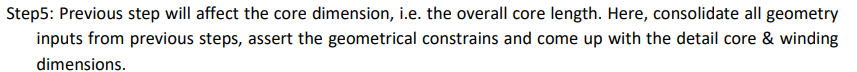

# Step 6

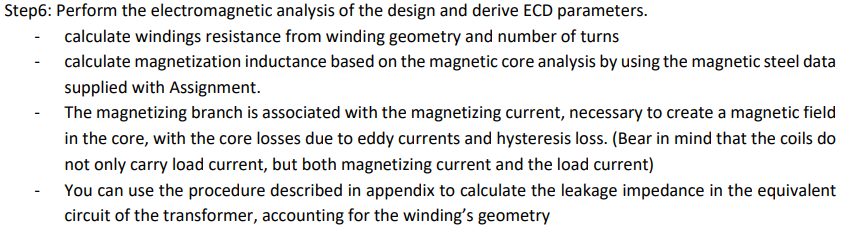

In [50]:
# 1) calculate windings resistance from winding geometry and number of turns 

# The winding resistance, can be found by using the formula R = rho * l / A, where rho is the resistivity of the material, l is the length of the conductor, and A is the cross-sectional area of the conductor. 
# The length of the conductor can be estimated based on the number of turns and the dimensions of the core. The cross-sectional area can be calculated based on the current density and the current carrying capacity of the conductor.

rho_copper = 1.68 * 10**(-8) # [Ohm*m]
rho_aluminium = 2.82 * 10**(-8) # [Ohm*m]

# NOTE: Placeholder values for length and area !!!!!
l_pri = 10 # [m]
A_cond_pri = 10 * 10**(-6) # [m^2]
l_sec = 10 # [m]
A_cond_sec = 10 * 10**(-6) # [m^2]

R_wco_pri = rho_copper * l_pri / A_cond_pri # [Ohm]
R_wal_pri = rho_aluminium * l_pri / A_cond_pri # [Ohm]
R_wco_sec = rho_copper * l_sec / A_cond_sec # [Ohm]
R_wal_sec = rho_aluminium * l_sec / A_cond_sec # [Ohm]

print(f"Resistance of the primary winding for copper: {R_wco_pri:.3f} Ohm")
print(f"Resistance of the primary winding for aluminium: {R_wal_pri:.3f} Ohm")
print(f"Resistance of the secondary winding for copper: {R_wco_sec:.3f} Ohm")
print(f"Resistance of the secondary winding for aluminium: {R_wal_sec:.3f} Ohm")


Resistance of the primary winding for copper: 0.017 Ohm
Resistance of the primary winding for aluminium: 0.028 Ohm
Resistance of the secondary winding for copper: 0.017 Ohm
Resistance of the secondary winding for aluminium: 0.028 Ohm


2) calculate magnetization inductance based on the magnetic core analysis by using the magnetic steel data supplied with Assignment.


We approximate it in Excel

This is for M1000
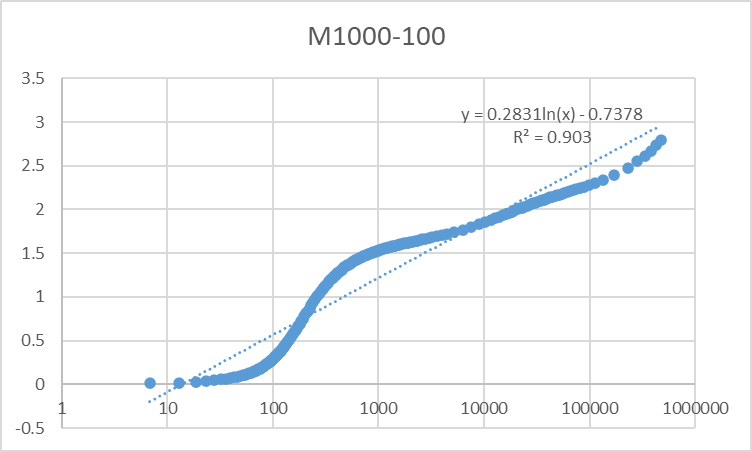

This is for M400
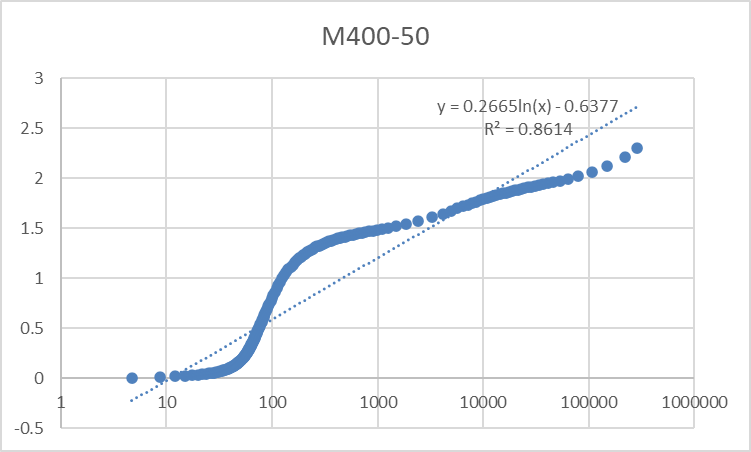

So, this means that for a local permeability, M1000 is approximated to

$
\frac{dB}{dH} = \mu = \frac{0.2831}{H}
$

And for M400
$
\mu = \frac{0.2665}{H}
$

In [51]:
import numpy as np

def find_mu(slope, H):
    # mu = slope / H, where H is the magnetic field strength in A/m
    mu = slope / H # [H/m]
    return mu

# Using these permeabilites, the reluctance of the core can be calculated
# R_core = l_core / mu*A_core, where l_core is the length of the magnetic path, mu_r is the relative permeability, mu_0 is the permeability of free space, and A_core is the cross-sectional area of the core.

def reluctance_core(l_core, mu, A_core):
    return l_core / (mu * A_core)

# For M400:
# B = 0.25 T -> H = 57.29616337 A/m
# B = 0.5 T -> H = 74.87686849 A/m
# B = 0.75 T -> H = 94.23517603 A/m
# B = 1 T -> H = 130.8565583 A/m
# B = 1.25 T -> H = 203.4908668 A/m
# B = 1.5 T -> H = 1267.375992 A/m
B_400 = [0.25, 0.5, 0.75, 1, 1.25, 1.5] # [T]
H_400 = [57.29616337, 74.87686849, 94.23517603, 130.8565583, 203.4908668, 1267.375992] # [A/m]
mu_400= [find_mu(0.2665, H) for H in H_400]

# For M1000:
# B = 0.25 T -> H = 91.93197858 A/m
# B = 0.5 T -> H = 139.2304245 A/m
# B = 0.75 T -> H = 191.6707459 A/m
# B = 1 T -> H = 263.0077027 A/m
# B = 1.25 T -> H = 394.3115448 A/m
# B = 1.5 T -> H = 847.4094384 A/m
B_1000 = B_400 # [T]
H_1000 = [91.93197858, 139.2304245, 191.6707459, 263.0077027, 394.3115448, 847.4094384] # [A/m]
mu_1000 = [find_mu(0.2831, H) for H in H_1000]

# NOTE: PUT IN THE RIGHT NUMBERS HERE FOR L_CORE
# The reluctance can be found for different scenarios:
R_core_400 = [reluctance_core(l_core=1, mu=mu_400[i], A_core=Area_core_pri) for i in range(len(mu_400))] # [A/Wb]
R_core_1000 = [reluctance_core(l_core=1, mu=mu_1000[i], A_core=Area_core_pri) for i in range(len(mu_1000))] # [A/Wb]

# Now the reluctance of the primary terminal can be found using the formula 
# L_core = N^2 / R_core, where N is the number of turns in the winding, and R_core is the reluctance of the core.

L_core_400 = [N_pri**2 / R for R in R_core_400] # [H]
L_core_1000 = [N_pri**2 / R for R in R_core_1000] # [H]

print("Inductance for M400:")
# Print B[i]: L_core_400[i] for i in range(len(B_400))
for i in range(len(B_400)):
    print(f"B = {B_400[i]:.2f} T: L_core = {L_core_400[i]:.3f} H")
print("\nInductance for M1000:")
for i in range(len(B_1000)):
    print(f"B = {B_1000[i]:.2f} T: L_core = {L_core_1000[i]:.3f} H")



Inductance for M400:
B = 0.25 T: L_core = 4466.790 H
B = 0.50 T: L_core = 3418.010 H
B = 0.75 T: L_core = 2715.864 H
B = 1.00 T: L_core = 1955.805 H
B = 1.25 T: L_core = 1257.697 H
B = 1.50 T: L_core = 201.937 H

Inductance for M1000:
B = 0.25 T: L_core = 2957.312 H
B = 0.50 T: L_core = 1952.673 H
B = 0.75 T: L_core = 1418.430 H
B = 1.00 T: L_core = 1033.702 H
B = 1.25 T: L_core = 689.484 H
B = 1.50 T: L_core = 320.827 H




3) The magnetizing branch is associated with the magnetizing current, necessary to create a magnetic field 
in the core, with the core losses due to eddy currents and hysteresis loss. (Bear in mind that the coils do 
not only carry load current, but both magnetizing current and the load current)

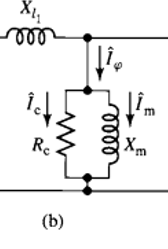

4) You can use the procedure described in appendix to calculate the leakage impedance in the equivalent 
circuit of the transformer, accounting for the winding’s geometry

# Step 7

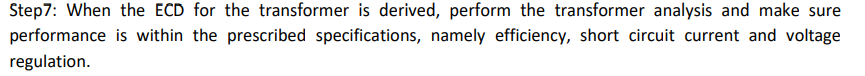